# STRF gradmaps: 2D-CNN on CRCNS AA2 (OV / conspecific)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/strf_gradmap_aa2.ipynb)

This notebook fits the **2D-CNN** of Pennington & David (2023) on a
slice of the **CRCNS AA2** auditory dataset (zebra finch ovoidalis,
OV — a thalamic nucleus relaying auditory information to forebrain
Field L) and extracts a **per-neuron STRF gradient map** from the
trained model — the canonical interpretable "what does this cell
respond to?" figure for nonlinear receptive-field models.

The 2D-CNN doesn't have an explicit STRF parameter to plot. Instead,
we ask: at the neuron's last-timestep prediction, what change in a
null spectrogram (zeros) most increases the response? Autodiff
gives that gradient in closed form — a `(F, T)` map per neuron.
The deepSTRF base class implements this in
`AudioEncodingModel.STRF_gradmap()`; the batch dimension parallelises
the calculation across all `N` output neurons in a single
forward / backward pass.

Scope: 59 OV cells × 20 conspecific stimuli at `dt_ms=5`. 100%
valid (s, n) coverage on this subset, so no NaN-aware bookkeeping
is exercised here — the same notebook on the full 494-cell, 117-
stim AA2 would be the next step (see "What's next").


## Setup — Google Colab

If you're running on Google Colab, the cell below installs deepSTRF
from source. Local installs (`pip install -e .`) are no-ops.

**Note on data**: AA2 is an authenticated CRCNS dataset. To
auto-download it, set `$CRCNS_USERNAME` and `$CRCNS_PASSWORD` (free
account at https://crcns.org/). On a local machine that already has
the data extracted, it's picked up from the cache automatically.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")


Local environment — assuming deepSTRF is already importable.


## Imports

In [2]:
%matplotlib inline
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.crcns_aa2 import CRCNSAA2Dataset
from deepSTRF.models.audio import ConvNet2D
from deepSTRF.training import Fitter, set_random_seed
from deepSTRF.utils import neural_collate, plot_strf_grid

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Load CRCNS AA2 — OV cells, conspecific stimuli only

We narrow the dataset at construction time via the `areas=` and
`stimuli=` arguments. A separate notebook covers the `select_*_by_attr`
runtime filtering API and the bidirectional rule from
`data_paradigm.md` §8; here we just want a clean small subset to
showcase gradmaps.

In [3]:
ds = CRCNSAA2Dataset(download=True, dt_ms=5, areas=('OV',), stimuli=('conspecific',))
print(f"OV + conspecific: N={ds.N_neurons} cells, S={len(ds.stims)} stims, "
      f"F={ds.F} bands, dt={ds.dt} ms")

T_min = min(s.shape[-1] for s in ds.stims)
T_max = max(s.shape[-1] for s in ds.stims)
print(f"stim T range: {T_min}..{T_max} frames "
      f"({T_min*ds.dt/1000:.2f} s .. {T_max*ds.dt/1000:.2f} s)")

valid_frac = ds.nrn_masks.float().mean().item()
print(f"valid (s, n) pairs: {100*valid_frac:.1f}%")


OV + conspecific: N=59 cells, S=20 stims, F=32 bands, dt=5 ms
stim T range: 234..511 frames (1.17 s .. 2.56 s)
valid (s, n) pairs: 100.0%


## 2. Train / val / test split + per-band standardisation

14 / 3 / 3 split, all conspecific. Standardisation statistics are
computed on train+val and applied to all stimuli — the held-out
test set is transformed with the same mean and std.

In [4]:
set_random_seed(0)
S = len(ds)
g = torch.Generator().manual_seed(0)
perm = torch.randperm(S, generator=g).tolist()
train_idx = perm[:14]
val_idx   = perm[14:17]
test_idx  = perm[17:20]
print(f"split: train {len(train_idx)} | val {len(val_idx)} | test {len(test_idx)}")

stats = ds.standardize_stims(stim_indices=train_idx + val_idx, per_band=True)
print(f"per-band mean range: [{stats['mean'].min():.3f}, {stats['mean'].max():.3f}]")
print(f"per-band std range:  [{stats['std'].min():.3f}, {stats['std'].max():.3f}]")


split: train 14 | val 3 | test 3
per-band mean range: [0.007, 1.557]
per-band std range:  [0.001, 1.433]


## 3. Build the 2D-CNN and fit

`ConvNet2D` is the deepSTRF port of Pennington & David's 2D-CNN:
three (Conv2d → CausalLayerNorm → LeakyReLU) blocks over the
spectrogram, then a 2-layer FC reading out the population. Default
`temporal_window_size = 3·(K_T − 1) = 24` frames (120 ms at our
5 ms resolution) sets the gradmap window we'll plot in section 5.

Hyperparameters:

- `batch_size=4` — with only 14 train stims, larger batches collapse
  to gradient descent (≤ 1 step per epoch) and lose SGD noise. On a
  bigger AA2 subset (more stims) you can dial this up, on this
  particular GPU up to ~32.
- `patience=50` on val cc_norm — the demo set is tiny so each
  epoch is quick and we can afford a long patience.
- `track_train_metrics=False` — skip the per-epoch recomputation of
  cc / cc_norm on the training accumulator; not useful at this
  scale and saves a few seconds per epoch.

In [5]:
N = ds.N_neurons
train_loader = DataLoader(Subset(ds, train_idx), batch_size=1,
                          shuffle=True, collate_fn=neural_collate)
val_loader   = DataLoader(Subset(ds, val_idx),   batch_size=1,
                          shuffle=False, collate_fn=neural_collate)
test_loader  = DataLoader(Subset(ds, test_idx),  batch_size=1,
                          shuffle=False, collate_fn=neural_collate)

set_random_seed(0)
model = ConvNet2D(
    n_frequency_bands=ds.F, kernel_size=(3, 9),
    c_hidden=10, n_hidden=20, out_neurons=N,
)
print(f"ConvNet2D params: {model.count_trainable_params():,}, "
      f"gradmap window: T={model.T} frames ({model.T * ds.dt} ms)")

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
fitter = Fitter(
    model, train_loader, val_loader,
    optimizer=optimizer, device=device,
    max_epochs=2000, patience=50,
    monitor="val_cc_norm", mode="max",
    track_train_metrics=False,
    # default log_fn prints per-epoch lines
)

t0 = time.time()
history = fitter.fit()
elapsed = time.time() - t0
print(f"\nfit completed: {len(history)} epochs in {elapsed/60:.1f} min")


ConvNet2D params: 12,401, gradmap window: T=24 frames (120 ms)


epoch    0 | train_loss=0.0554 | val_loss=0.0456 | val_cc=0.0113 | val_cc_norm=0.0055


epoch    1 | train_loss=0.0450 | val_loss=0.0388 | val_cc=0.0360 | val_cc_norm=0.0248


epoch    2 | train_loss=0.0385 | val_loss=0.0352 | val_cc=0.0702 | val_cc_norm=0.0615


epoch    3 | train_loss=0.0351 | val_loss=0.0329 | val_cc=0.1782 | val_cc_norm=0.1957


...

epoch  127 | train_loss=0.0165 | val_loss=0.0226 | val_cc=0.5192 | val_cc_norm=0.6642


epoch  128 | train_loss=0.0164 | val_loss=0.0230 | val_cc=0.5174 | val_cc_norm=0.6618


epoch  129 | train_loss=0.0162 | val_loss=0.0230 | val_cc=0.5169 | val_cc_norm=0.6613


epoch  130 | train_loss=0.0161 | val_loss=0.0226 | val_cc=0.5217 | val_cc_norm=0.6681


epoch  131 | train_loss=0.0161 | val_loss=0.0230 | val_cc=0.5150 | val_cc_norm=0.6587

fit completed: 132 epochs in 0.7 min


## 4. Test-set summary

test cc:      +0.497
test cc_norm: +0.653


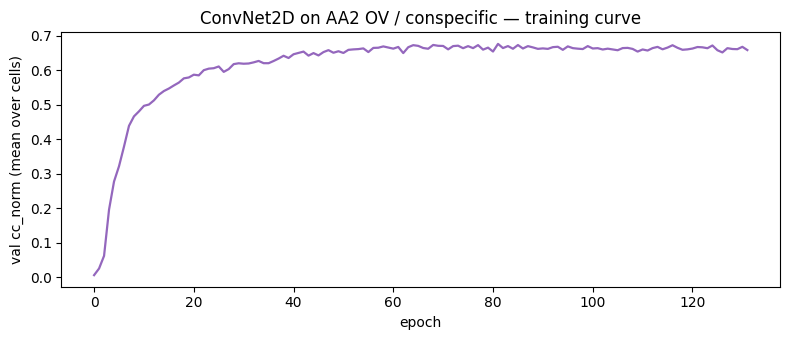

In [6]:
test = fitter.evaluate(test_loader)
test_cc_norm = test["cc_norm"].cpu()
test_cc      = test["cc"].cpu()
print(f"test cc:      {torch.nanmean(test_cc):+.3f}")
print(f"test cc_norm: {torch.nanmean(test_cc_norm):+.3f}")

# Training curve
fig, ax = plt.subplots(figsize=(8, 3.5))
ep = [h["epoch"] for h in history]
vC = [torch.nanmean(h["val_cc_norm"]).item() for h in history]
ax.plot(ep, vC, lw=1.6, color='tab:purple')
ax.set_xlabel("epoch"); ax.set_ylabel("val cc_norm (mean over cells)")
ax.set_title("ConvNet2D on AA2 OV / conspecific — training curve")
plt.tight_layout(); plt.show()


## 5. STRF gradmaps for the best-predicted cells

`model.STRF_gradmap()` returns a `(N, 1, F, T)` tensor — for each
output neuron, the gradient $\partial \mathcal{L}_n / \partial \mathbf{x}_0$
of the negative last-timestep activity with respect to a null
(all-zero) spectrogram. Under this sign convention positive entries
are *inhibitory* features — adding mass there would decrease the
neuron's response (see
[`README_gradmap_strf.md`](../md/README_gradmap_strf.md) §4 for the
full derivation). To get the more intuitive *excitatory-as-positive*
plot — red = features the cell prefers — we plot $-\mathbf{g}_n$,
i.e. negate the returned gradmaps before passing them to
`plot_strf_grid`.

This is the closest thing a nonlinear model can give you to a
classical reverse-correlation STRF, and it's the right diagnostic
for asking "did the network learn something biologically sensible?"
— particularly when the model has no explicit STRF layer.

We pick the 12 best-predicted OV cells (highest test `cc_norm`).
Time runs left to right in units of milliseconds of history.
Frequency runs bottom to top (low → high band). Diverging colormap
`RdBu_r` with per-cell symmetric scale so the spatial structure is
easy to read across cells of varying gradient magnitude.

gradmaps shape: (59, 32, 24)
top 12 cells, cc_norm range: 0.967 ... 0.792


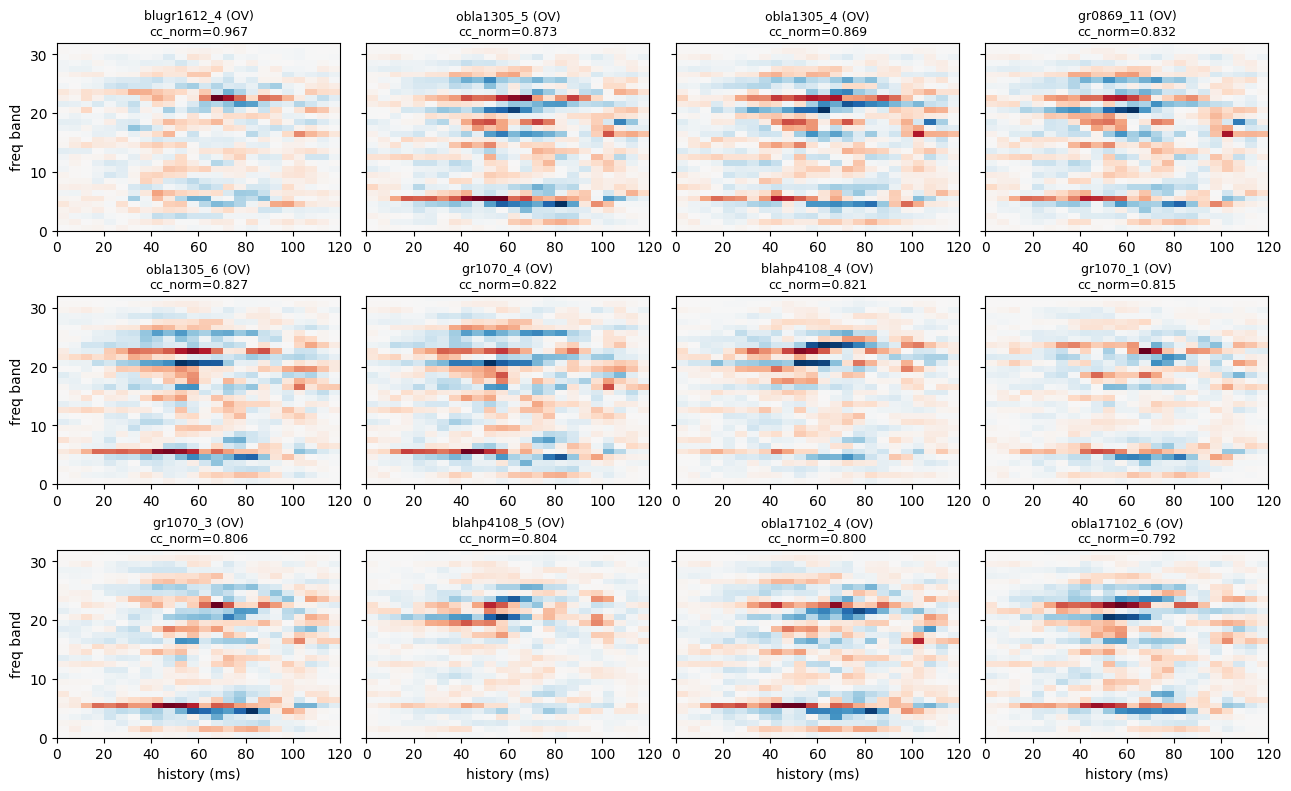

In [7]:
model.eval()
gradmaps = model.STRF_gradmap()                        # (N, 1, F, T)
gradmaps = gradmaps.squeeze(1).detach().cpu().numpy()  # (N, F, T)
print(f"gradmaps shape: {gradmaps.shape}")

K = 12
test_arr = test_cc_norm.numpy()
order = np.argsort(np.where(np.isnan(test_arr), -np.inf, test_arr))[::-1]
top_idx = order[:K]
print(f"top {K} cells, cc_norm range: "
      f"{test_arr[top_idx[0]]:.3f} ... {test_arr[top_idx[-1]]:.3f}")

# Negate so that red (positive) = excitatory under RdBu_r — see the
# markdown above and README_gradmap_strf.md §4 for the sign convention.
titles = [f"{ds.nrn_meta[n]['cell_id'][:14]} ({ds.nrn_meta[n]['area']})\n"
          f"cc_norm={test_arr[n]:.3f}"
          for n in top_idx]
plot_strf_grid(
    -gradmaps[top_idx], titles=titles, dt_ms=ds.dt, ncols=4,
    figsize=(4 * 3.2, 3 * 2.6),
)
plt.show()

## What's next

- **Scale up to the full AA2 population.** Drop `areas=` and
  `stimuli=` from the dataset constructor to fit the full 494
  cells × 117 stims. Each epoch becomes ~80 s on a single GPU
  rather than a few seconds, but the gradmap pipeline is
  identical. Useful for comparing receptive-field structure
  across MLd / Field L / OV / CM at the population level.
- **Sustained-loss gradmaps.** The current `STRF_gradmap` uses the
  last-timestep activity as the loss target — a Spike-Triggered-
  Average view. A complementary diagnostic is the gradient of the
  *time-averaged* activity, which highlights features that drive
  sustained responses rather than transient ones.
- **Cross-model comparison.** Run the same gradmap extraction on a
  Linear / LinearNonlinear model fit to the same split, and
  overlay the explicit STRF kernel against the gradient map. They
  should agree closely on the L/LN models, and the difference
  between ConvNet2D's gradmap and an LN's STRF is exactly the
  nonlinear contribution.
